# Import packages and datasets

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from simulator import simulate
import pandas as pd

In [2]:
infected_df = pd.read_csv("infected_timeseries.csv")
rewiring_df = pd.read_csv("rewiring_timeseries.csv")
degree_df = pd.read_csv("final_degree_histograms.csv")

infected_values = []
for i in range(0, 40):
    df = infected_df[infected_df["replicate_id"] == i]
    result = df["infected_fraction"].values
    infected_values.append(np.array(result))

rewiring_values = []
for i in range(0, 40):
    df = rewiring_df[rewiring_df["replicate_id"] == i]
    result = df["rewire_count"].values
    rewiring_values.append(np.array(result))

degree_values = []
for i in range(0, 40):
    df = degree_df[degree_df["replicate_id"] == i]
    result = df["count"].values
    degree_values.append(np.array(result))
    
infected_values = np.array(infected_values)
rewiring_values = np.array(rewiring_values)
degree_values = np.array(degree_values)


# split train and test
rng = np.random.default_rng(42)
train_index = rng.choice(np.arange(40), size =32, replace = False )

# mean of 32 train obs
obs_infected = np.mean(infected_values[train_index], axis = 0)
obs_rewiring = np.mean(rewiring_values[train_index], axis = 0)
obs_degree = np.mean(degree_values[train_index], axis = 0)

# mean of 8 test obs
test_index = np.setdiff1d(np.arange(len(infected_values)), train_index)
test_obs_infected = np.mean(infected_values[test_index], axis = 0)
test_obs_rewiring = np.mean(rewiring_values[test_index], axis = 0)
test_obs_degree = np.mean(degree_values[test_index], axis = 0)

print(obs_infected.shape)
print(obs_rewiring.shape)
print(obs_degree.shape)

print(infected_values[test_index].shape)
print(test_obs_infected.shape)
print(test_obs_rewiring.shape)
print(test_obs_degree.shape)

(201,)
(201,)
(31,)
(8, 201)
(201,)
(201,)
(31,)


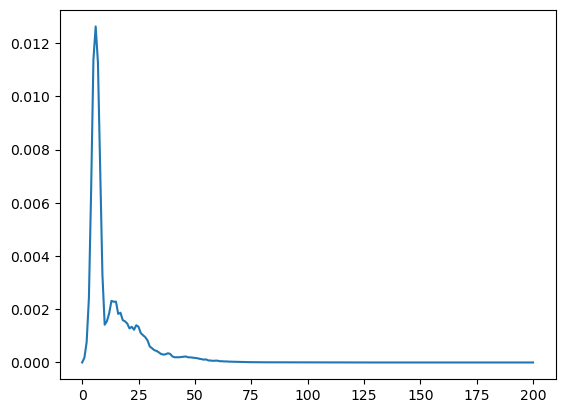

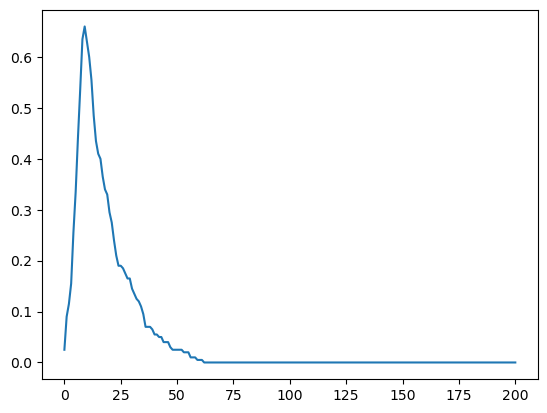

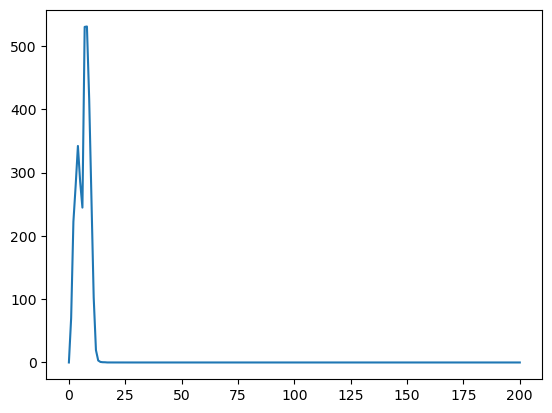

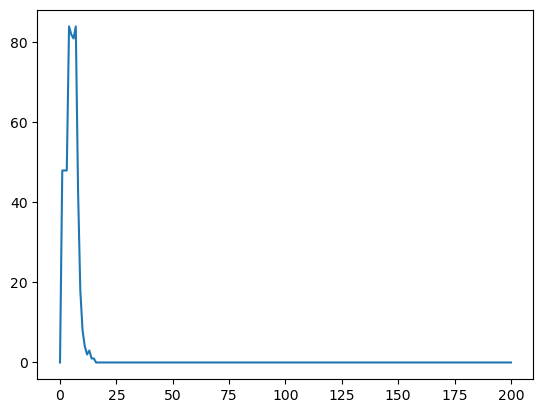

In [3]:
# var
plt.plot(range(201), np.var(np.array(infected_values).T, axis=1))

# compared with real y
plt.figure()
plt.plot(range(201),infected_values[35] )

plt.figure()
plt.plot(range(201), np.var(np.array(rewiring_values).T, axis=1))

plt.figure()
plt.plot(range(201),rewiring_values[35] )

<Figure size 640x480 with 0 Axes>

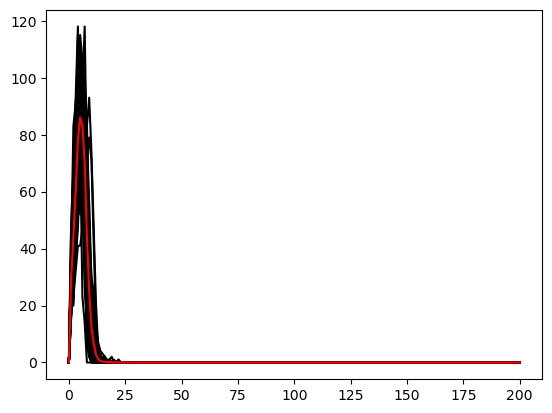

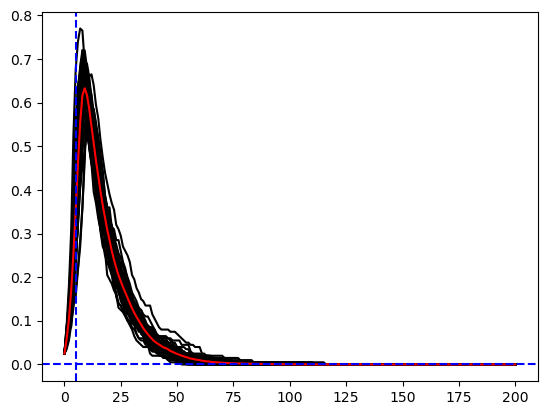

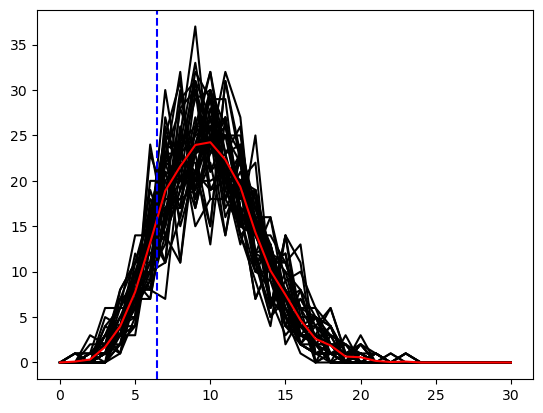

<Figure size 640x480 with 0 Axes>

In [4]:
# check mean of obs

for i in range(0, 40):
    plt.plot(range(201),rewiring_values[i], color= 'black')
plt.plot(range(201), np.mean(np.array(rewiring_values).T, axis = 1), color='red')

plt.figure()
for i in range(0, 40):
    plt.plot(range(201),infected_values[i], color = 'black')
plt.plot(range(201), np.mean(np.array(infected_values).T, axis = 1), color= 'red')
plt.axvline(x = 5,   linestyle = '--', color = 'blue')
plt.axhline(y = 0,   linestyle = '--', color = 'blue')

plt.figure()
for i in range(0, 40):
    plt.plot(range(31), degree_values[i], color = 'black')
plt.plot(range(31), np.mean(np.array(degree_values).T, axis = 1), color = 'red')
plt.axvline(x = np.mean(np.mean(np.array(degree_values).T, axis = 1)),   linestyle = '--', color = 'blue')

plt.figure()

# sim_data

In [5]:
beta_list = []
gamma_list = []
rho_list = []
sim_infected = []
sim_rewiring = []
sim_degree = []

N_sim = 20_000

for _ in range(N_sim):
    # generate prior
    beta_prior = rng.uniform(0.05, 0.5)
    gamma_prior = rng.uniform(0.02, 0.2)
    rho_prior = rng.uniform(0, 0.8)
    
    beta_list.append(beta_prior)
    gamma_list.append(gamma_prior)
    rho_list.append(rho_prior)
    
    # sim_data
    infected, rewires, degrees = simulate(beta = beta_prior, gamma = gamma_prior, rho = rho_prior, rng = rng)
    
    sim_infected.append(infected)
    sim_rewiring.append(rewires)
    sim_degree.append(degrees)

beta_list = np.array(beta_list)
gamma_list = np.array(gamma_list)
rho_list = np.array(rho_list)
sim_infected = np.array(sim_infected)
sim_rewiring = np.array(sim_rewiring)
sim_degree = np.array(sim_degree)

# Summary statistics

### 1. choose a set of summary statistics (using 5% acceptance, norm distance function)
evaluation metric:  
generate 50 samples from posterior parameters list.  
using these parameters to generate path (50 paths).  
compute squared norm/norm of summary statistics between each of 50 path and test path.  
compute avg, smaller, better

transmission - beta: the force that make epidemic growth  
Higher β = faster, bigger epidemic. 
higher peak infected, faster time to peak, faster initial growth  
  
control - gamma, rho: the force that slow or stop the epidemic  
Recovery: Infected people get better and stop spreading.  
Rewiring: Susceptible people cut edges to infected — behavioral control.  
Both γ and ρ reduce the epidemic size, but in completely different ways. 

The problem:  
Both control forces make the epidemic smaller, so:  
A small epidemic can be caused by:  
low transmission (low β), strong recovery (high γ), strong rewiring (high ρ)  
That’s why you need:  
Infection stats → measure transmission strength  
Rewiring + degree stats → measure behavioral control (ρ)  
Final size / duration → measure recovery control (γ)

peak_infected: separate beta from gamma, rho  
time_to_peak_infected: informative for beta  
total_infected (AUC): share between beta, gamma, rho, but useful when combined with others(duration/width/slope)  
initial_growth: informative for beta  
intial_slope: informative for beta, less noisy than single step  
  
duration: informative for gamma, separate from beta and rho  
time_from_peak_to_end: informative for gamma, separte from beta and rho  
width_at_half_peak: informative for gamma, separate from beta and rho

total_rewire: informative for rho (most important stats for identifying rho)  
peak_rewire: Helps tell apart: High β → many infections → many rewires / High ρ → many rewires even with moderate infection  
time_to_peak_rewire: separate beta and rho  
correlation: informative for rho, special for adaptive network  
  
mean_final_degree: informative for rho  
var_final_degree: informative for rho  
  
ratio: good for separate beta and rho

Infection-based stats (peak, growth rate, timing) mainly identify β and weakly constrain γ.
Rewiring-based stats (total rewires, correlation, peak rewiring) directly measure ρ.
Final degree stats are unique network signals for ρ that infection data cannot replicate.
The rewire/infection ratio is especially powerful because it distinguishes whether low infection is caused by fast recovery, fast transmission with strong behavior, or weak transmission.

Final useful conclusion
Using only infection statistics leaves β and ρ nearly unidentifiable.Adding rewiring + degree + ratio statistics gives full information touniquely recover all three parameters.

In [238]:
np.mean(time_to_peak_infected2)

6.80635

In [241]:
def check_all_zero_after_first_zero(infected_data):
    all_valid = True
    for idx, path in enumerate(infected_data):
        first_zero_idx = np.argmax(path < 1e-6)
        
        if first_zero_idx == 0 and path[0] > 1e-6:
            continue

        after_zero = path[first_zero_idx:]
        still_infected = np.sum(after_zero > 1e-6)
        
        if still_infected > 0:
            print(f"no")
            all_valid = False
    
    return all_valid

check_all_zero_after_first_zero(np.array(infected_values))

True

In [9]:
"""
train 


# beta:
peak_infected = np.max(obs_infected)
time_to_peak_infected = np.argmax(obs_infected)
total_Infected = np.sum(obs_infected)                            # AUC
initial_growth = obs_infected[1]/obs_infected[0]
initial_slope = obs_infected[5]-obs_infected[0]
duration = np.sum(obs_infected > 1e-6)
time_from_peak_to_end = duration - time_to_peak_infected

# rho:
total_rewire = np.sum(obs_rewiring)
peak_rewire = np.max(obs_rewiring)
time_to_peak_rewire = np.argmax(obs_rewiring)
correlation = np.corrcoef(obs_infected, obs_rewiring)[0,1]
mean_final_degree = np.mean(obs_degree)
var_final_degree = np.var(obs_degree)
ratio = np.sum(obs_rewiring)/np.sum(obs_infected)

# gamma:
width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)


"""

# for computing std
peak_infected2 = np.max(sim_infected, axis = 1)
time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
total_Infected2 = np.sum(sim_infected, axis=1)                            
initial_growth2 = sim_infected.T[1]/sim_infected.T[0]
initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
duration2 = np.sum(sim_infected > 1e-6, axis = 1)
time_from_peak_to_end2 = duration2 - time_to_peak_infected2
       
total_rewire2 = np.sum(sim_rewiring, axis = 1)
peak_rewire2 = np.max(sim_rewiring, axis = 1)
time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

cov = np.mean(( sim_infected- np.mean(sim_infected, axis=1, keepdims=True)) * (sim_rewiring - np.mean(sim_rewiring, axis = 1,keepdims=True)), axis=1)
denom = sim_infected.std(axis=1) * sim_rewiring.std(axis=1)
correlation2 = np.zeros_like(denom)
valid = denom > 0
correlation2[valid] = cov[valid] / denom[valid]

mean_final_degree2 = np.mean(sim_degree, axis =1)
var_final_degree2 = np.var(sim_degree, axis = 1)

ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)




"""

test: 

peak_infected3 = np.max(test_obs_infected)
time_to_peak_infected3 = np.argmax(test_obs_infected)
total_Infected3 = np.sum(test_obs_infected)                            # AUC
initial_growth3 = test_obs_infected[1]/test_obs_infected[0]
initial_slope3 = test_obs_infected[5]-test_obs_infected[0]
duration3 = np.sum(test_obs_infected > 1e-6)
       
total_rewire3 = np.sum(test_obs_rewiring)
peak_rewire3 = np.max(test_obs_rewiring)
time_to_peak_rewire3 = np.argmax(test_obs_rewiring)
correlation3 = np.corrcoef(test_obs_infected, test_obs_rewiring)[0,1]

mean_final_degree3 = np.mean(test_obs_degree)
var_final_degree3 = np.var(test_obs_degree)

ratio3 = np.sum(test_obs_rewiring)/np.sum(test_obs_infected)
width_at_half_peak3 = np.sum(test_obs_infected > np.max(test_obs_infected)/2)
time_from_peak_to_end3 = duration3 - time_to_peak_infected3

"""





################
# normalization#
################

peak_infected_std = np.std(peak_infected2)
time_to_peak_infected_std = np.std(time_to_peak_infected2)
total_Infected_std = np.std(total_Infected2)                            
initial_growth_std = np.std(initial_growth2)
initial_slope_std = np.std(initial_slope2)
duration_std = np.std(duration2)
       
total_rewire_std = np.std(total_rewire2)
peak_rewire_std = np.std(peak_rewire2)
time_to_peak_rewire_std = np.std(time_to_peak_rewire2)
correlation_std = np.std(correlation2)

mean_final_degree_std = np.std(mean_final_degree2)
var_final_degree_std = np.std(var_final_degree2)

ratio_std = np.std(ratio2)
width_at_half_peak_std = np.std(width_at_half_peak2)
time_from_peak_to_end_std = np.std(time_from_peak_to_end2)


"""
train :

peak_infected_norm = peak_infected /peak_infected_std
time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
total_Infected_norm = total_Infected / total_Infected_std
initial_growth_norm = initial_growth / initial_growth_std
initial_slope_norm = initial_slope/ initial_slope_std
duration_norm = duration/ duration_std
time_from_peak_to_end_norm  = time_from_peak_to_end /  time_from_peak_to_end_std
       
total_rewire_norm = total_rewire / total_rewire_std
peak_rewire_norm = peak_rewire / peak_rewire_std
time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
correlation_norm = correlation/ correlation_std

mean_final_degree_norm = mean_final_degree / mean_final_degree_std
var_final_degree_norm = var_final_degree/ var_final_degree_std

ratio_norm  = ratio / ratio_std
width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 



# sim
peak_infected_norm2 = peak_infected2 /peak_infected_std
time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
total_Infected_norm2 = total_Infected2 / total_Infected_std
initial_growth_norm2 = initial_growth2 / initial_growth_std
initial_slope_norm2 = initial_slope2/ initial_slope_std
duration_norm2 = duration2/ duration_std
time_from_peak_to_end_norm2  = time_from_peak_to_end2 /  time_from_peak_to_end_std
       
total_rewire_norm2 = total_rewire2 / total_rewire_std
peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
correlation_norm2 = correlation2/ correlation_std

mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
var_final_degree_norm2 = var_final_degree2/ var_final_degree_std

ratio_norm2  = ratio2 / ratio_std
width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 


# test
peak_infected_norm3 = peak_infected3 /peak_infected_std
time_to_peak_infected_norm3 = time_to_peak_infected3/ time_to_peak_infected_std
total_Infected_norm3 = total_Infected3 / total_Infected_std
initial_growth_norm3 = initial_growth3 / initial_growth_std
initial_slope_norm3 = initial_slope3/ initial_slope_std
duration_norm3 = duration3/ duration_std
time_from_peak_to_end_norm3  = time_from_peak_to_end3 /  time_from_peak_to_end_std
       
total_rewire_norm3 = total_rewire3 / total_rewire_std
peak_rewire_norm3 = peak_rewire3 / peak_rewire_std
time_to_peak_rewire_norm3 =  time_to_peak_rewire3 / time_to_peak_rewire_std
correlation_norm3 = correlation3/ correlation_std

mean_final_degree_norm3 = mean_final_degree3 / mean_final_degree_std
var_final_degree_norm3 = var_final_degree3/ var_final_degree_std

ratio_norm3  = ratio3 / ratio_std
width_at_half_peak_norm3 = width_at_half_peak3 / width_at_half_peak_std 


"""

'\ntrain :\n\npeak_infected_norm = peak_infected /peak_infected_std\ntime_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std\ntotal_Infected_norm = total_Infected / total_Infected_std\ninitial_growth_norm = initial_growth / initial_growth_std\ninitial_slope_norm = initial_slope/ initial_slope_std\nduration_norm = duration/ duration_std\ntime_from_peak_to_end_norm  = time_from_peak_to_end /  time_from_peak_to_end_std\n       \ntotal_rewire_norm = total_rewire / total_rewire_std\npeak_rewire_norm = peak_rewire / peak_rewire_std\ntime_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std\ncorrelation_norm = correlation/ correlation_std\n\nmean_final_degree_norm = mean_final_degree / mean_final_degree_std\nvar_final_degree_norm = var_final_degree/ var_final_degree_std\n\nratio_norm  = ratio / ratio_std\nwidth_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std \n\n\n\n# sim\npeak_infected_norm2 = peak_infected2 /peak_infected_std\ntime_to_pe

In [10]:

def accept_indices(distance, acceptance_rate):     
    eps = np.quantile(distance, acceptance_rate)
    indices = np.where(distance <= eps)[0]
    
    beta_accepted = beta_list[indices]
    gamma_accepted = gamma_list[indices]
    rho_accepted = rho_list[indices]
    return indices, beta_accepted, gamma_accepted, rho_accepted

def test_on_summary(accepted_indices, s):
    posterior_test_indices = rng.choice(accepted_indices, size = s, replace = False)

    beta_test_posterior = beta_list[posterior_test_indices]
    gamma_test_posterior = gamma_list[posterior_test_indices]
    rho_test_posterior = rho_list[posterior_test_indices]

    posterior_test_infected = []
    posterior_test_rewiring = []
    posterior_test_degree = []

    for i in range(s):
        beta_posterior = beta_test_posterior[i]
        gamma_posterior = gamma_test_posterior[i]
        rho_posterior = rho_test_posterior[i]
        
        infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
        
        posterior_test_infected.append(infected)
        posterior_test_rewiring.append(rewires)
        posterior_test_degree.append(degrees)

    posterior_test_infected = np.array(posterior_test_infected)
    posterior_test_rewiring = np.array(posterior_test_rewiring)
    posterior_test_degree = np.array(posterior_test_degree)

    return posterior_test_infected, posterior_test_rewiring, posterior_test_degree



def plot_beta_across_summary(posterior):
    plt.figure()
    for i in range(len(posterior)):
      plt.hist(posterior[i], density = True, bins = 50, label = f"set{i+1}", histtype='step') 
      plt.axvline(x = np.mean(posterior[i]),   linestyle = '--', label = f'set{i+1} mean')

    x_axis_beta = np.linspace(0.05, 0.5, 100)
    y_axis_beta = np.ones(100) * (1/0.45)
    plt.plot(x_axis_beta, y_axis_beta)
    plt.axvline(x = 0.55/2,  linestyle = '--', label = 'prior mean', color = 'purple')
    plt.legend()

def plot_gamma_across_summary(posterior):
    plt.figure()
    for i in range(len(posterior)):
      plt.hist(posterior[i], density = True, bins = 50, label = f"set{i+1}", histtype='step') 
      plt.axvline(x = np.mean(posterior[i]),   linestyle = '--', label = f'set{i+1} mean')

    x_axis_gamma = np.linspace(0.02, 0.2, 100)
    y_axis_gamma = np.ones(100) * (1/0.18)
    plt.plot(x_axis_gamma, y_axis_gamma)
    plt.axvline(x = 0.22/2,  linestyle = '--', label = 'prior mean', color = 'purple')
    plt.legend() 


def plot_rho_across_summary(posterior):
    plt.figure()
    for i in range(len(posterior)):
      plt.hist(posterior[i], density = True, bins = 50, label = f"set{i+1}", histtype='step') 
      plt.axvline(x = np.mean(posterior[i]),   linestyle = '--', label = f'set{i+1} mean')

    x_axis_rho = np.linspace(0, 0.8, 100)
    y_axis_rho = np.ones(100) * (1/0.8)
    plt.plot(x_axis_rho, y_axis_rho)
    plt.axvline(x = 0.8/2,  linestyle = '--', label = 'prior mean', color = 'red')
    plt.legend()  


Test1: full set 

[  
      
    peak_infected,
    time_to_peak_infected,
    total_Infected,
    initial_growth,
    initial_slope,

    duration,
    width_at_half_peak,

    total_rewire,
    peak_rewire,
    time_to_peak_rewire,
    ratio,

    mean_final_degree,
    var_final_degree
]

In [11]:
def full_set_summary_obs(obs_infected, obs_rewiring, obs_degree):       # 13
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_growth = obs_infected[1]/obs_infected[0]
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_growth_norm = initial_growth / initial_growth_std
    initial_slope_norm = initial_slope/ initial_slope_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    var_final_degree_norm = var_final_degree/ var_final_degree_std
    ratio_norm  = ratio / ratio_std
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    
    return peak_infected_norm, time_to_peak_infected_norm, total_Infected_norm, initial_growth_norm, initial_slope_norm, total_rewire_norm, peak_rewire_norm, time_to_peak_rewire_norm, mean_final_degree_norm, var_final_degree_norm, ratio_norm, width_at_half_peak_norm, duration_norm



def full_set_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_growth2 = sim_infected.T[1]/sim_infected.T[0]
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis = 1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_growth_norm2 = initial_growth2 / initial_growth_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
        
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    var_final_degree_norm2 = var_final_degree2/ var_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    
    return peak_infected_norm2, time_to_peak_infected_norm2, total_Infected_norm2, initial_growth_norm2, initial_slope_norm2, total_rewire_norm2, peak_rewire_norm2, time_to_peak_rewire_norm2, mean_final_degree_norm2, var_final_degree_norm2, ratio_norm2, width_at_half_peak_norm2,  duration_norm2


In [12]:
summary_test1_train = full_set_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test1_sim = full_set_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test1_test = full_set_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test1_sim = np.array(summary_test1_sim).T
summary_test1_train = np.array(summary_test1_train)
summary_test1_test = np.array(summary_test1_test)


distance = np.linalg.norm(summary_test1_train - summary_test1_sim, axis = 1)      
                                                 
indices_test1_5, beta_test1_5, gamma_test1_5, rho_test1_5  = accept_indices(distance, 0.05)

posterior_test1_infected, posterior_test1_rewiring, posterior_test1_degree = test_on_summary(indices_test1_5, 50)

summary_test1_post= full_set_summary_sim(posterior_test1_infected, posterior_test1_rewiring, posterior_test1_degree)
summary_test1_post = np.array(summary_test1_post).T


error = np.mean(np.linalg.norm(summary_test1_test - summary_test1_post, axis = 1)**2  )
print(error)
print(np.std(beta_test1_5))
print(np.std(gamma_test1_5))
print(np.std(rho_test1_5))

4.7019387680817575
0.05310162994624523
0.026667938362876887
0.1186471746717012


Test 2: reduce redundant information
[  
      
    peak_infected,
    total_Infected,
    initial_slope,
    <time_to_peak>

    duration,
    width_at_half_peak,

    total_rewire,
    peak_rewire,
    ratio,
    mean_final_degree,
]

In [13]:
def set_2_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_slope_norm = initial_slope/ initial_slope_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    var_final_degree_norm = var_final_degree / var_final_degree_std
    ratio_norm  = ratio / ratio_std
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    
    return peak_infected_norm, total_Infected_norm, initial_slope_norm, total_rewire_norm, peak_rewire_norm, mean_final_degree_norm, ratio_norm, width_at_half_peak_norm, duration_norm



def set_2_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis = 1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
        
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    var_final_degree_norm2 = var_final_degree2 / var_final_degree_std
    
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    
    return peak_infected_norm2, total_Infected_norm2, initial_slope_norm2, total_rewire_norm2, peak_rewire_norm2, mean_final_degree_norm2, ratio_norm2, width_at_half_peak_norm2, duration_norm2

In [14]:
summary_test2_train = set_2_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test2_sim = set_2_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test2_test = set_2_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test2_sim = np.array(summary_test2_sim).T
summary_test2_train = np.array(summary_test2_train)
summary_test2_test = np.array(summary_test2_test)

distance = np.linalg.norm(summary_test2_train - summary_test2_sim, axis = 1)      
                                                 
indices_test2_5, beta_test2_5, gamma_test2_5, rho_test2_5  = accept_indices(distance, 0.05)

posterior_test2_infected, posterior_test2_rewiring, posterior_test2_degree = test_on_summary(indices_test2_5, 50)

summary_test2_post= set_2_summary_sim(posterior_test2_infected, posterior_test2_rewiring, posterior_test2_degree)
summary_test2_post = np.array(summary_test2_post).T


error = np.mean(np.linalg.norm(summary_test2_test - summary_test2_post, axis = 1)**2  )
print(error)
print(np.std(beta_test2_5))
print(np.std(gamma_test2_5))
print(np.std(rho_test2_5))

2.5324636173047073
0.05603510089246679
0.021856544315946514
0.1131877638146663


Test 3:
[  
      
      peak_infected,
    total_Infected,

    duration,

    total_rewire,
    peak_rewire,
    ratio,
    mean_final_degree,
    ]

In [15]:
def set_3_summary_obs(obs_infected, obs_rewiring, obs_degree):       # 7 stats
    
    peak_infected = np.max(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC

    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)

    duration = np.sum(obs_infected > 1e-6)
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std

    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    ratio_norm  = ratio / ratio_std
    
    duration_norm = duration/ duration_std
    
    return peak_infected_norm, total_Infected_norm, total_rewire_norm, ratio_norm, duration_norm, peak_rewire_norm, mean_final_degree_norm



def set_3_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    mean_final_degree2 = np.mean(sim_degree, axis =1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std

    duration_norm2 = duration2/ duration_std
    
    return peak_infected_norm2, total_Infected_norm2, total_rewire_norm2, ratio_norm2, duration_norm2, peak_rewire_norm2, mean_final_degree_norm2


In [16]:
summary_test3_train = set_3_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test3_sim = set_3_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test3_test = set_3_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test3_sim = np.array(summary_test3_sim).T
summary_test3_train = np.array(summary_test3_train)
summary_test3_test = np.array(summary_test3_test)

distance = np.linalg.norm(summary_test3_train - summary_test3_sim, axis = 1)      
                                                 
indices_test3_5, beta_test3_5, gamma_test3_5, rho_test3_5  = accept_indices(distance, 0.05)

posterior_test3_infected, posterior_test3_rewiring, posterior_test3_degree = test_on_summary(indices_test3_5, 50)

summary_test3_post= set_3_summary_sim(posterior_test3_infected, posterior_test3_rewiring, posterior_test3_degree)
summary_test3_post = np.array(summary_test3_post).T


error = np.mean(np.linalg.norm(summary_test3_test - summary_test3_post, axis = 1)**2  )
print(error)
print(np.std(beta_test3_5))
print(np.std(gamma_test3_5))
print(np.std(rho_test3_5))

1.3486269117142407
0.09720525242194593
0.01913885778732837
0.09086971007575138


Test 4: reduce redundant information
[  
      
    peak_infected,
    duration,
    total_rewire,
    ratio,
    mean_final_degree,
]

In [17]:
def set_4_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_slope_norm = initial_slope/ initial_slope_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    ratio_norm  = ratio / ratio_std
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    
    return peak_infected_norm, total_rewire_norm, mean_final_degree_norm, duration_norm, ratio_norm



def set_4_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
        
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    
    return peak_infected_norm2, total_rewire_norm2, mean_final_degree_norm2, duration_norm2, ratio_norm2

In [18]:

summary_test4_train = set_4_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test4_sim = set_4_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test4_test = set_4_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test4_sim = np.array(summary_test4_sim).T
summary_test4_train = np.array(summary_test4_train)
summary_test4_test = np.array(summary_test4_test)

distance = np.linalg.norm(summary_test4_train - summary_test4_sim, axis = 1)      
                                               
indices_test4_5, beta_test4_5, gamma_test4_5, rho_test4_5  = accept_indices(distance, 0.05)




posterior_test4_infected, posterior_test4_rewiring, posterior_test4_degree = test_on_summary(indices_test4_5, 50)

summary_test4_post= set_4_summary_sim(posterior_test4_infected, posterior_test4_rewiring, posterior_test4_degree)
summary_test4_post = np.array(summary_test4_post).T



error = np.mean(np.linalg.norm(summary_test4_test - summary_test4_post, axis = 1)**2  )
print(error)
print(np.std(beta_test4_5))
print(np.std(gamma_test4_5))
print(np.std(rho_test4_5))

0.8902492884023647
0.12100079927550453
0.018473204198388504
0.14182022925707022


test 5: 
[  
      
    peak_infected,
    time_to_peak_infected,
    <time_from_peak_to_end>   --> can test if remove is better
    total_Infected,
    total_rewire,
    ratio
]

In [19]:
def set_5_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
   
    total_rewire = np.sum(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    duration = np.sum(obs_infected > 1e-6)
    time_from_peak_to_end = duration - time_to_peak_infected
    
    
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    
    total_rewire_norm = total_rewire / total_rewire_std
    ratio_norm  = ratio / ratio_std
    time_from_peak_to_end_norm = time_from_peak_to_end / time_from_peak_to_end_std
    
    return peak_infected_norm, time_to_peak_infected_norm, total_Infected_norm, total_rewire_norm, ratio_norm, time_from_peak_to_end_norm



def set_5_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    time_from_peak_to_end2 = duration2 - time_to_peak_infected2
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    time_from_peak_to_end_norm2 = time_from_peak_to_end2/time_from_peak_to_end_std
    
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    ratio_norm2  = ratio2 / ratio_std
    return peak_infected_norm2, time_to_peak_infected_norm2, total_Infected_norm2, total_rewire_norm2, ratio_norm2, time_from_peak_to_end_norm2

In [20]:
summary_test5_train = set_5_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test5_sim = set_5_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test5_test = set_5_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test5_sim = np.array(summary_test5_sim).T
summary_test5_train = np.array(summary_test5_train)
summary_test5_test = np.array(summary_test5_test)

distance = np.linalg.norm(summary_test5_train - summary_test5_sim, axis = 1)

indices_test5_5, beta_test5_5, gamma_test5_5, rho_test5_5  = accept_indices(distance, 0.05)


posterior_test5_infected, posterior_test5_rewiring, posterior_test5_degree = test_on_summary(indices_test5_5, 50)

summary_test5_post= set_5_summary_sim(posterior_test5_infected, posterior_test5_rewiring, posterior_test5_degree)
summary_test5_post = np.array(summary_test5_post).T


error = np.mean(np.linalg.norm(summary_test5_test - summary_test5_post, axis = 1)**2  )
print(error)
print(np.std(beta_test5_5))
print(np.std(gamma_test5_5))
print(np.std(rho_test5_5))

1.604946263229326
0.09513073456862176
0.017116300988302156
0.13762794834463798


try remove:

In [21]:
def set_5_summary_obs(obs_infected, obs_rewiring, obs_degree):

    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC

    total_rewire = np.sum(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)



    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std

    total_rewire_norm = total_rewire / total_rewire_std
    ratio_norm  = ratio / ratio_std

    return peak_infected_norm, time_to_peak_infected_norm, total_Infected_norm, total_rewire_norm, ratio_norm



def set_5_summary_sim(sim_infected, sim_rewiring, sim_degree):

    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)

    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std

    total_rewire_norm2 = total_rewire2 / total_rewire_std
    ratio_norm2  = ratio2 / ratio_std
    return peak_infected_norm2, time_to_peak_infected_norm2, total_Infected_norm2, total_rewire_norm2, ratio_norm2

In [22]:
summary_test5_train = set_5_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test5_sim = set_5_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test5_test = set_5_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test5_sim = np.array(summary_test5_sim).T
summary_test5_train = np.array(summary_test5_train)
summary_test5_test = np.array(summary_test5_test)

distance = np.linalg.norm(summary_test5_train - summary_test5_sim, axis = 1)

indices_test5_5, beta_test52_5, gamma_test52_5, rho_test52_5  = accept_indices(distance, 0.05)


posterior_test5_infected, posterior_test5_rewiring, posterior_test5_degree = test_on_summary(indices_test5_5, 50)

summary_test5_post= set_5_summary_sim(posterior_test5_infected, posterior_test5_rewiring, posterior_test5_degree)
summary_test5_post = np.array(summary_test5_post).T


error = np.mean(np.linalg.norm(summary_test5_test - summary_test5_post, axis = 1)**2  )
print(error)
print(np.std(beta_test52_5))
print(np.std(gamma_test52_5))
print(np.std(rho_test52_5))

0.8441001683507386
0.07004095624248953
0.02236416397320395
0.11304706738590034


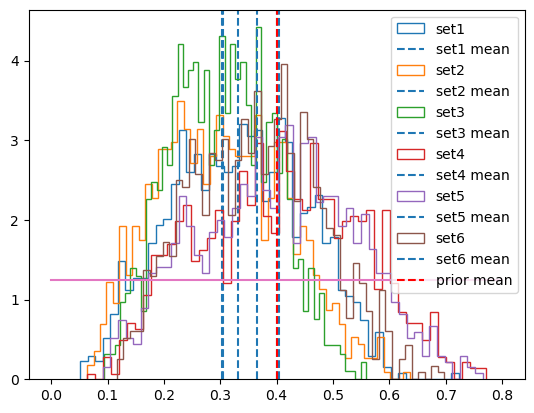

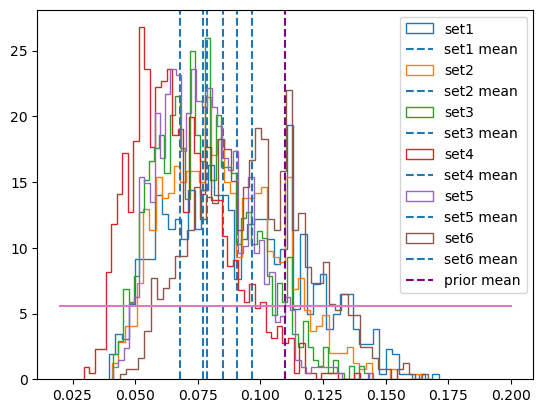

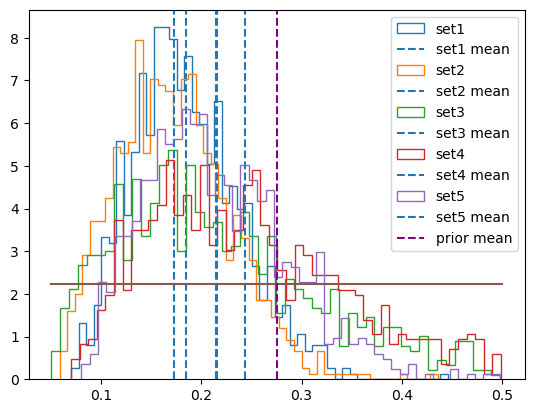

In [ ]:
plot_rho_across_summary([rho_test1_5, rho_test2_5, rho_test3_5,rho_test4_5, rho_test5_5,rho_test52_5]) 
plot_gamma_across_summary([  gamma_test1_5, gamma_test2_5, gamma_test3_5, gamma_test4_5, gamma_test5_5, gamma_test52_5])      
plot_beta_across_summary([  beta_test1_5, beta_test2_5,beta_test3_5, beta_test4_5, beta_test5_5, beta_test52_5])

1. check stability?
2. acceptance rates
3. distance function

In [ ]:
"""
# 10% acceptance rate: 
indices_test1_10, beta_test1_10, gamma_test1_10, rho_test1_10  = accept_indices(distance, 0.1)

# 10% acceptance with adjustment: 
diff = ( summary_sim1 - summary_obs1)[indices_test1_10]
ones = np.ones((len(indices_test1_10), 1))
design = np.hstack([ones, diff])
accepted_pais = np.array([beta_test1_10, gamma_test1_10, rho_test1_10]).T
coefficients = np.linalg.lstsq(design, accepted_pais, rcond=None)[0]     

beta_coef = coefficients[1:]          
accepted_pais_adj = accepted_pais - diff @ beta_coef

beta_test1_10_adj = accepted_pais_adj.T[0]
gamma_test1_10_adj = accepted_pais_adj.T[1] 
rho_test1_10_adj = accepted_pais_adj.T[2]
"""

# Reference

### test4:

[
    peak_infected,
    time_to_peak_infected,
    total_Infected,
    duration,
    total_rewire,
    time_to_peak_rewire,
    correlation,
    ratio
]

In [629]:
def set_4_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_slope_norm = initial_slope/ initial_slope_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    ratio_norm  = ratio / ratio_std
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    
    return peak_infected_norm, time_to_peak_infected_norm, total_Infected_norm, total_rewire_norm, ratio_norm, duration_norm, time_to_peak_rewire_norm



def set_4_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
        
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    
    return peak_infected_norm2, time_to_peak_infected_norm2, total_Infected_norm2, total_rewire_norm2, ratio_norm2, duration_norm2, time_to_peak_rewire_norm2


In [630]:
summary_test4_train = set_4_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test4_sim = set_4_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test4_test = set_4_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test4_sim = np.array(summary_test4_sim).T
summary_test4_train = np.array(summary_test4_train)
summary_test4_test = np.array(summary_test4_test)

In [631]:
distance = np.linalg.norm(summary_test4_train - summary_test4_sim, axis = 1)      

# 5% acceptance rate:                                                   
indices_test4_5, beta_test4_5, gamma_test4_5, rho_test4_5  = accept_indices(distance, 0.05)

In [632]:
# test
posterior_test4_indices = rng.choice(indices_test4_5, size = 50, replace = False)

beta_test4_posterior = beta_list[posterior_test4_indices]
gamma_test4_posterior = gamma_list[posterior_test4_indices]
rho_test4_posterior = rho_list[posterior_test4_indices]

posterior_test4_infected = []
posterior_test4_rewiring = []
posterior_test4_degree = []

for i in range(50):
    beta_posterior = beta_test4_posterior[i]
    gamma_posterior = gamma_test4_posterior[i]
    rho_posterior = rho_test4_posterior[i]
    
    infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
    
    posterior_test4_infected.append(infected)
    posterior_test4_rewiring.append(rewires)
    posterior_test4_degree.append(degrees)

posterior_test4_infected = np.array(posterior_test4_infected)
posterior_test4_rewiring = np.array(posterior_test4_rewiring)
posterior_test4_degree = np.array(posterior_test4_degree)

summary_test4_post= set_4_summary_sim(posterior_test4_infected, posterior_test4_rewiring, posterior_test4_degree)
summary_test4_post = np.array(summary_test4_post).T


error = np.mean(np.linalg.norm(summary_test4_test - summary_test4_post, axis = 1)**2  )
print(error)
print(np.std(beta_test4_5))
print(np.std(gamma_test4_5))
print(np.std(rho_test4_5))

1.7822602957475246
0.08749066195635713
0.017934718744976718
0.14271660976042944


test3:                             ---> not in colab
(if beta hard to infer)  

[
    peak_infected,
    total_Infected,
    duration,
    initial_growth,
    initial_slope,
    total_rewire,
    correlation,
    ratio
]

In [633]:
def set_4_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)
    correlation = np.corrcoef(obs_infected, obs_rewiring)[0,1]

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_slope_norm = initial_slope/ initial_slope_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    ratio_norm  = ratio / ratio_std
    correlation_norm = correlation/correlation_std
    
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    var_final_degree_norm = var_final_degree/var_final_degree_std
    
    return peak_infected_norm, total_Infected_norm, initial_slope_norm, total_rewire_norm, ratio_norm, duration_norm, mean_final_degree_norm, time_to_peak_rewire_norm



def set_4_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis =1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    cov = np.mean(( sim_infected- np.mean(sim_infected, axis=1, keepdims=True)) * (sim_rewiring - np.mean(sim_rewiring, axis = 1,keepdims=True)), axis=1)
    denom = sim_infected.std(axis=1) * sim_rewiring.std(axis=1)
    correlation2 = np.zeros_like(denom)
    valid = denom > 0
    correlation2[valid] = cov[valid] / denom[valid]
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
    var_final_degree_norm2 = var_final_degree2/var_final_degree_std
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    correlation_norm2 = correlation2 / correlation_std
    
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    
    return peak_infected_norm2, total_Infected_norm2, initial_slope_norm2, total_rewire_norm2, ratio_norm2, duration_norm2, mean_final_degree_norm2, time_to_peak_rewire_norm2

In [634]:
summary_test4_train = set_4_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test4_sim = set_4_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test4_test = set_4_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test4_sim = np.array(summary_test4_sim).T
summary_test4_train = np.array(summary_test4_train)
summary_test4_test = np.array(summary_test4_test)

In [635]:
distance = np.linalg.norm(summary_test4_train - summary_test4_sim, axis = 1)      

# 5% acceptance rate:                                                   
indices_test4_5, beta_test4_5, gamma_test4_5, rho_test4_5  = accept_indices(distance, 0.05)

In [636]:
# test
posterior_test4_indices = rng.choice(indices_test4_5, size = 50, replace = False)

beta_test4_posterior = beta_list[posterior_test4_indices]
gamma_test4_posterior = gamma_list[posterior_test4_indices]
rho_test4_posterior = rho_list[posterior_test4_indices]

posterior_test4_infected = []
posterior_test4_rewiring = []
posterior_test4_degree = []

for i in range(50):
    beta_posterior = beta_test4_posterior[i]
    gamma_posterior = gamma_test4_posterior[i]
    rho_posterior = rho_test4_posterior[i]
    
    infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
    
    posterior_test4_infected.append(infected)
    posterior_test4_rewiring.append(rewires)
    posterior_test4_degree.append(degrees)

posterior_test4_infected = np.array(posterior_test4_infected)
posterior_test4_rewiring = np.array(posterior_test4_rewiring)
posterior_test4_degree = np.array(posterior_test4_degree)

summary_test4_post= set_4_summary_sim(posterior_test4_infected, posterior_test4_rewiring, posterior_test4_degree)
summary_test4_post = np.array(summary_test4_post).T


error = np.mean(np.linalg.norm(summary_test4_test - summary_test4_post, axis = 1)**2  )
print(error)
print(np.std(beta_test4_5))
print(np.std(gamma_test4_5))
print(np.std(rho_test4_5))

2.2099654127524238
0.07154527938905589
0.022109073106805613
0.1549314330492486


[
    peak_infected,
    time_to_peak_infected,
    total_Infected,

    duration,                # γ (light addition)

    total_rewire,
    ratio
]

In [544]:
def set_4_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_slope_norm = initial_slope/ initial_slope_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    ratio_norm  = ratio / ratio_std
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    var_final_degree_norm = var_final_degree/var_final_degree_std
    
    return peak_infected_norm, time_to_peak_infected_norm, total_Infected_norm, duration_norm, total_rewire_norm, ratio_norm



def set_4_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis =1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
    var_final_degree_norm2 = var_final_degree2/var_final_degree_std
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    
    return peak_infected_norm2, time_to_peak_infected_norm2, total_Infected_norm2, duration_norm2, total_rewire_norm2, ratio_norm2

In [545]:
summary_test4_train = set_4_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test4_sim = set_4_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test4_test = set_4_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test4_sim = np.array(summary_test4_sim).T
summary_test4_train = np.array(summary_test4_train)
summary_test4_test = np.array(summary_test4_test)

In [546]:
distance = np.linalg.norm(summary_test4_train - summary_test4_sim, axis = 1)      

# 5% acceptance rate:                                                   
indices_test4_5, beta_test4_5, gamma_test4_5, rho_test4_5  = accept_indices(distance, 0.05)

In [547]:
# test
posterior_test4_indices = rng.choice(indices_test4_5, size = 50, replace = False)

beta_test4_posterior = beta_list[posterior_test4_indices]
gamma_test4_posterior = gamma_list[posterior_test4_indices]
rho_test4_posterior = rho_list[posterior_test4_indices]

posterior_test4_infected = []
posterior_test4_rewiring = []
posterior_test4_degree = []

for i in range(50):
    beta_posterior = beta_test4_posterior[i]
    gamma_posterior = gamma_test4_posterior[i]
    rho_posterior = rho_test4_posterior[i]
    
    infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
    
    posterior_test4_infected.append(infected)
    posterior_test4_rewiring.append(rewires)
    posterior_test4_degree.append(degrees)

posterior_test4_infected = np.array(posterior_test4_infected)
posterior_test4_rewiring = np.array(posterior_test4_rewiring)
posterior_test4_degree = np.array(posterior_test4_degree)

summary_test4_post= set_4_summary_sim(posterior_test4_infected, posterior_test4_rewiring, posterior_test4_degree)
summary_test4_post = np.array(summary_test4_post).T


error = np.mean(np.linalg.norm(summary_test4_test - summary_test4_post, axis = 1)**2  )
print(error)
print(np.std(beta_test4_5))
print(np.std(gamma_test4_5))
print(np.std(rho_test4_5))

1.527948419676867
0.09408258792799175
0.017260986305481032
0.1411486656000599


[
    peak_infected,
    time_to_peak_infected,
    total_Infected,

    duration,
    time_from_peak_to_end,   # ← KEY improvement

    total_rewire,
    ratio
]

In [550]:
def set_4_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_slope = obs_infected[5]-obs_infected[0]
    

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    time_from_peak_to_end = duration - time_to_peak_infected
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_slope_norm = initial_slope/ initial_slope_std
    time_from_peak_to_end_norm = time_from_peak_to_end / time_from_peak_to_end_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    ratio_norm  = ratio / ratio_std
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    var_final_degree_norm = var_final_degree/var_final_degree_std
    
    return peak_infected_norm, time_to_peak_infected_norm, total_Infected_norm, duration_norm, total_rewire_norm, ratio_norm, time_from_peak_to_end_norm



def set_4_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis =1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    time_from_peak_to_end2 = duration2 - time_to_peak_infected2
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
    var_final_degree_norm2 = var_final_degree2/var_final_degree_std
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    
    time_from_peak_to_end_norm2 = time_from_peak_to_end2/time_from_peak_to_end_std
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    
    return peak_infected_norm2, time_to_peak_infected_norm2, total_Infected_norm2, duration_norm2, total_rewire_norm2, ratio_norm2, time_from_peak_to_end_norm2

In [551]:
summary_test4_train = set_4_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test4_sim = set_4_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test4_test = set_4_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test4_sim = np.array(summary_test4_sim).T
summary_test4_train = np.array(summary_test4_train)
summary_test4_test = np.array(summary_test4_test)

In [552]:
distance = np.linalg.norm(summary_test4_train - summary_test4_sim, axis = 1)      

# 5% acceptance rate:                                                   
indices_test4_5, beta_test4_5, gamma_test4_5, rho_test4_5  = accept_indices(distance, 0.05)

In [553]:
# test
posterior_test4_indices = rng.choice(indices_test4_5, size = 50, replace = False)

beta_test4_posterior = beta_list[posterior_test4_indices]
gamma_test4_posterior = gamma_list[posterior_test4_indices]
rho_test4_posterior = rho_list[posterior_test4_indices]

posterior_test4_infected = []
posterior_test4_rewiring = []
posterior_test4_degree = []

for i in range(50):
    beta_posterior = beta_test4_posterior[i]
    gamma_posterior = gamma_test4_posterior[i]
    rho_posterior = rho_test4_posterior[i]
    
    infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
    
    posterior_test4_infected.append(infected)
    posterior_test4_rewiring.append(rewires)
    posterior_test4_degree.append(degrees)

posterior_test4_infected = np.array(posterior_test4_infected)
posterior_test4_rewiring = np.array(posterior_test4_rewiring)
posterior_test4_degree = np.array(posterior_test4_degree)

summary_test4_post= set_4_summary_sim(posterior_test4_infected, posterior_test4_rewiring, posterior_test4_degree)
summary_test4_post = np.array(summary_test4_post).T


error = np.mean(np.linalg.norm(summary_test4_test - summary_test4_post, axis = 1)**2  )
print(error)
print(np.std(beta_test4_5))
print(np.std(gamma_test4_5))
print(np.std(rho_test4_5))

2.1063920414920294
0.10124446678403322
0.016083001403580845
0.15301990594784035


[
    peak_infected,
    time_to_peak_infected,
    total_Infected,

    duration,

    total_rewire,
    correlation,   # ← NEW (replace noisy timing)
    ratio
]

In [554]:
def set_4_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_slope = obs_infected[5]-obs_infected[0]
    

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)
    correlation = np.corrcoef(obs_infected, obs_rewiring)[0,1]

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    time_from_peak_to_end = duration - time_to_peak_infected
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_slope_norm = initial_slope/ initial_slope_std
    time_from_peak_to_end_norm = time_from_peak_to_end / time_from_peak_to_end_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    ratio_norm  = ratio / ratio_std
    correlation_norm = correlation/ correlation_std
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    var_final_degree_norm = var_final_degree/var_final_degree_std
    
    return peak_infected_norm, time_to_peak_infected_norm, total_Infected_norm, duration_norm, total_rewire_norm, ratio_norm, correlation_norm



def set_4_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis =1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    time_from_peak_to_end2 = duration2 - time_to_peak_infected2
    cov = np.mean(( sim_infected- np.mean(sim_infected, axis=1, keepdims=True)) * (sim_rewiring - np.mean(sim_rewiring, axis = 1,keepdims=True)), axis=1)
    denom = sim_infected.std(axis=1) * sim_rewiring.std(axis=1)
    correlation2 = np.zeros_like(denom)
    valid = denom > 0
    correlation2[valid] = cov[valid] / denom[valid]
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
    var_final_degree_norm2 = var_final_degree2/var_final_degree_std
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    
    time_from_peak_to_end_norm2 = time_from_peak_to_end2/time_from_peak_to_end_std
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    correlation_norm2 = correlation2/correlation_std
    
    return peak_infected_norm2, time_to_peak_infected_norm2, total_Infected_norm2, duration_norm2, total_rewire_norm2, ratio_norm2, correlation_norm2

In [555]:
summary_test4_train = set_4_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test4_sim = set_4_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test4_test = set_4_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test4_sim = np.array(summary_test4_sim).T
summary_test4_train = np.array(summary_test4_train)
summary_test4_test = np.array(summary_test4_test)

In [556]:
distance = np.linalg.norm(summary_test4_train - summary_test4_sim, axis = 1)      

# 5% acceptance rate:                                                   
indices_test4_5, beta_test4_5, gamma_test4_5, rho_test4_5  = accept_indices(distance, 0.05)

In [557]:
# test
posterior_test4_indices = rng.choice(indices_test4_5, size = 50, replace = False)

beta_test4_posterior = beta_list[posterior_test4_indices]
gamma_test4_posterior = gamma_list[posterior_test4_indices]
rho_test4_posterior = rho_list[posterior_test4_indices]

posterior_test4_infected = []
posterior_test4_rewiring = []
posterior_test4_degree = []

for i in range(50):
    beta_posterior = beta_test4_posterior[i]
    gamma_posterior = gamma_test4_posterior[i]
    rho_posterior = rho_test4_posterior[i]
    
    infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
    
    posterior_test4_infected.append(infected)
    posterior_test4_rewiring.append(rewires)
    posterior_test4_degree.append(degrees)

posterior_test4_infected = np.array(posterior_test4_infected)
posterior_test4_rewiring = np.array(posterior_test4_rewiring)
posterior_test4_degree = np.array(posterior_test4_degree)

summary_test4_post= set_4_summary_sim(posterior_test4_infected, posterior_test4_rewiring, posterior_test4_degree)
summary_test4_post = np.array(summary_test4_post).T


error = np.mean(np.linalg.norm(summary_test4_test - summary_test4_post, axis = 1)**2  )
print(error)
print(np.std(beta_test4_5))
print(np.std(gamma_test4_5))
print(np.std(rho_test4_5))

1.9834974075790917
0.08574188433734274
0.019183257029458955
0.14579504043558633


[
    peak_infected,
    time_to_peak_infected,
    total_Infected,

    duration,
    time_from_peak_to_end,

    total_rewire,
    correlation,
    ratio
]

In [558]:
def set_4_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_slope = obs_infected[5]-obs_infected[0]
    

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)
    correlation = np.corrcoef(obs_infected, obs_rewiring)[0,1]

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    time_from_peak_to_end = duration - time_to_peak_infected
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_slope_norm = initial_slope/ initial_slope_std
    time_from_peak_to_end_norm = time_from_peak_to_end / time_from_peak_to_end_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    ratio_norm  = ratio / ratio_std
    correlation_norm = correlation/ correlation_std
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    var_final_degree_norm = var_final_degree/var_final_degree_std
    
    return peak_infected_norm, time_to_peak_infected_norm, total_Infected_norm, duration_norm, time_from_peak_to_end_norm, total_rewire_norm, ratio_norm, correlation_norm



def set_4_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis =1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    time_from_peak_to_end2 = duration2 - time_to_peak_infected2
    cov = np.mean(( sim_infected- np.mean(sim_infected, axis=1, keepdims=True)) * (sim_rewiring - np.mean(sim_rewiring, axis = 1,keepdims=True)), axis=1)
    denom = sim_infected.std(axis=1) * sim_rewiring.std(axis=1)
    correlation2 = np.zeros_like(denom)
    valid = denom > 0
    correlation2[valid] = cov[valid] / denom[valid]
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
    var_final_degree_norm2 = var_final_degree2/var_final_degree_std
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    
    time_from_peak_to_end_norm2 = time_from_peak_to_end2/time_from_peak_to_end_std
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    correlation_norm2 = correlation2/correlation_std
    
    return peak_infected_norm2, time_to_peak_infected_norm2, total_Infected_norm2, duration_norm2, time_from_peak_to_end_norm2, total_rewire_norm2, ratio_norm2, correlation_norm2

In [559]:
summary_test4_train = set_4_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test4_sim = set_4_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test4_test = set_4_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test4_sim = np.array(summary_test4_sim).T
summary_test4_train = np.array(summary_test4_train)
summary_test4_test = np.array(summary_test4_test)

In [560]:
distance = np.linalg.norm(summary_test4_train - summary_test4_sim, axis = 1)      

# 5% acceptance rate:                                                   
indices_test4_5, beta_test4_5, gamma_test4_5, rho_test4_5  = accept_indices(distance, 0.05)

In [561]:
# test
posterior_test4_indices = rng.choice(indices_test4_5, size = 50, replace = False)

beta_test4_posterior = beta_list[posterior_test4_indices]
gamma_test4_posterior = gamma_list[posterior_test4_indices]
rho_test4_posterior = rho_list[posterior_test4_indices]

posterior_test4_infected = []
posterior_test4_rewiring = []
posterior_test4_degree = []

for i in range(50):
    beta_posterior = beta_test4_posterior[i]
    gamma_posterior = gamma_test4_posterior[i]
    rho_posterior = rho_test4_posterior[i]
    
    infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
    
    posterior_test4_infected.append(infected)
    posterior_test4_rewiring.append(rewires)
    posterior_test4_degree.append(degrees)

posterior_test4_infected = np.array(posterior_test4_infected)
posterior_test4_rewiring = np.array(posterior_test4_rewiring)
posterior_test4_degree = np.array(posterior_test4_degree)

summary_test4_post= set_4_summary_sim(posterior_test4_infected, posterior_test4_rewiring, posterior_test4_degree)
summary_test4_post = np.array(summary_test4_post).T


error = np.mean(np.linalg.norm(summary_test4_test - summary_test4_post, axis = 1)**2  )
print(error)
print(np.std(beta_test4_5))
print(np.std(gamma_test4_5))
print(np.std(rho_test4_5))

2.7332471549533603
0.09338755494598944
0.01797487488280596
0.1606026652582035


# Reference

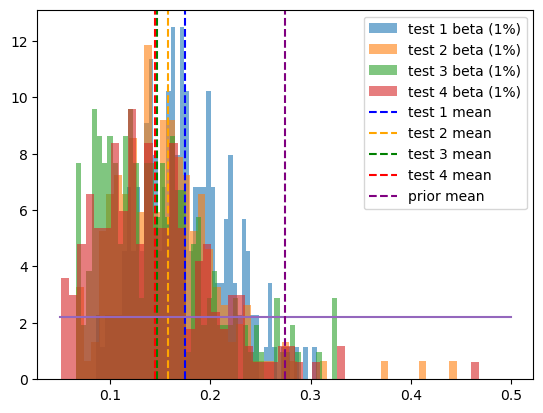

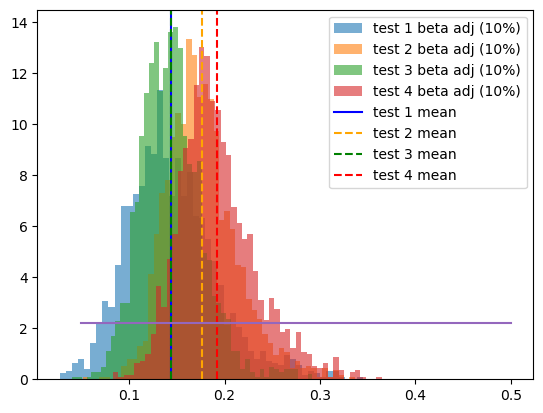

In [80]:
# beta: 1%
plt.figure()
plt.hist(beta_accepted, density = True, bins = 50, label = "test 1 beta (1%)", alpha = 0.6) 
plt.hist(beta_accepted3, density = True, bins = 50, label = "test 2 beta (1%)", alpha = 0.6) 
plt.hist(beta_accepted5, density = True, bins = 50, label = "test 3 beta (1%)", alpha = 0.6) 
plt.hist(beta_accepted7, density = True, bins = 50, label = "test 4 beta (1%)", alpha = 0.6) 
plt.axvline(x = np.mean(beta_accepted),  linestyle = '--', label = 'test 1 mean', color = 'blue')
plt.axvline(x = np.mean(beta_accepted3),  linestyle = '--', label = 'test 2 mean', color = 'orange')
plt.axvline(x = np.mean(beta_accepted5),  linestyle = '--', label = 'test 3 mean', color = 'green')
plt.axvline(x = np.mean(beta_accepted7),  linestyle = '--', label = 'test 4 mean', color = 'red')
x_axis_beta = np.linspace(0.05, 0.5, 100)
y_axis_beta = np.ones(100) * (1/0.45)
plt.plot(x_axis_beta, y_axis_beta)
plt.axvline(x = 0.55/2,  linestyle = '--', label = 'prior mean', color = 'purple')
plt.legend()

# beta: 10% adj
plt.figure()
plt.hist(beta_accepted2_adj, density = True, bins = 50, label = "test 1 beta adj (10%)", alpha = 0.6) 
plt.hist(beta_accepted4_adj, density = True, bins = 50, label = "test 2 beta adj (10%)", alpha = 0.6) 
plt.hist(beta_accepted6_adj, density = True, bins = 50, label = "test 3 beta adj (10%)", alpha = 0.6) 
plt.hist(beta_accepted8_adj, density = True, bins = 50, label = "test 4 beta adj (10%)", alpha = 0.6) 
plt.axvline(x = np.mean(beta_accepted2_adj),   label = 'test 1 mean', color = 'blue')
plt.axvline(x = np.mean(beta_accepted4_adj),  linestyle = '--', label = 'test 2 mean', color = 'orange')
plt.axvline(x = np.mean(beta_accepted6_adj),  linestyle = '--', label = 'test 3 mean', color = 'green')
plt.axvline(x = np.mean(beta_accepted8_adj),  linestyle = '--', label = 'test 4 mean', color = 'red')
x_axis_beta = np.linspace(0.05, 0.5, 100)
y_axis_beta = np.ones(100) * (1/0.45)
plt.plot(x_axis_beta, y_axis_beta)
plt.legend()


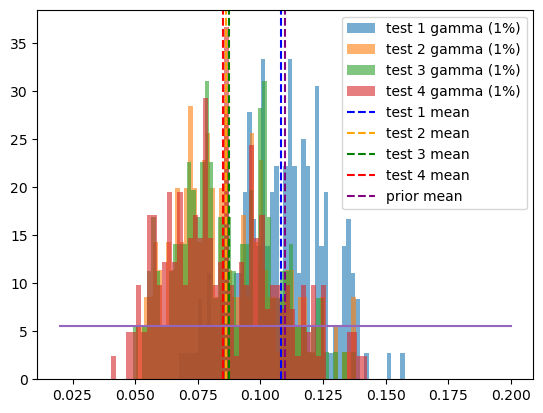

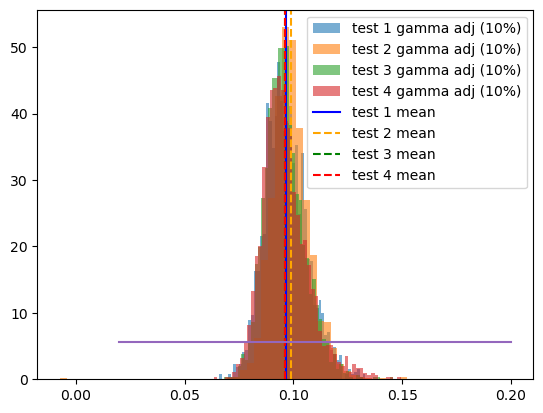

In [81]:
# gamma: 1%
plt.figure()
plt.hist(gamma_accepted, density = True, bins = 50, label = "test 1 gamma (1%)", alpha = 0.6) 
plt.hist(gamma_accepted3, density = True, bins = 50, label = "test 2 gamma (1%)", alpha = 0.6) 
plt.hist(gamma_accepted5, density = True, bins = 50, label = "test 3 gamma (1%)", alpha = 0.6) 
plt.hist(gamma_accepted7, density = True, bins = 50, label = "test 4 gamma (1%)", alpha = 0.6) 
plt.axvline(x = np.mean(gamma_accepted),  linestyle = '--', label = 'test 1 mean', color = 'blue')
plt.axvline(x = np.mean(gamma_accepted3),  linestyle = '--', label = 'test 2 mean', color = 'orange')
plt.axvline(x = np.mean(gamma_accepted5),  linestyle = '--', label = 'test 3 mean', color = 'green')
plt.axvline(x = np.mean(gamma_accepted7),  linestyle = '--', label = 'test 4 mean', color = 'red')
x_axis_gamma = np.linspace(0.02, 0.2, 100)
y_axis_gamma = np.ones(100) * (1/0.18)
plt.plot(x_axis_gamma, y_axis_gamma)
plt.axvline(x = 0.22/2,  linestyle = '--', label = 'prior mean', color = 'purple')
plt.legend()


# gamma: 10% adj
plt.figure()
plt.hist(gamma_accepted2_adj, density = True, bins = 50, label = "test 1 gamma adj (10%)", alpha = 0.6) 
plt.hist(gamma_accepted4_adj, density = True, bins = 50, label = "test 2 gamma adj (10%)", alpha = 0.6) 
plt.hist(gamma_accepted6_adj, density = True, bins = 50, label = "test 3 gamma adj (10%)", alpha = 0.6) 
plt.hist(gamma_accepted8_adj, density = True, bins = 50, label = "test 4 gamma adj (10%)", alpha = 0.6) 
plt.axvline(x = np.mean(gamma_accepted2_adj),   label = 'test 1 mean', color = 'blue')
plt.axvline(x = np.mean(gamma_accepted4_adj),  linestyle = '--', label = 'test 2 mean', color = 'orange')
plt.axvline(x = np.mean(gamma_accepted6_adj),  linestyle = '--', label = 'test 3 mean', color = 'green')
plt.axvline(x = np.mean(gamma_accepted8_adj),  linestyle = '--', label = 'test 4 mean', color = 'red')
x_axis_gamma = np.linspace(0.02, 0.2, 100)
y_axis_gamma = np.ones(100) * (1/0.18)
plt.plot(x_axis_gamma, y_axis_gamma)
plt.legend()


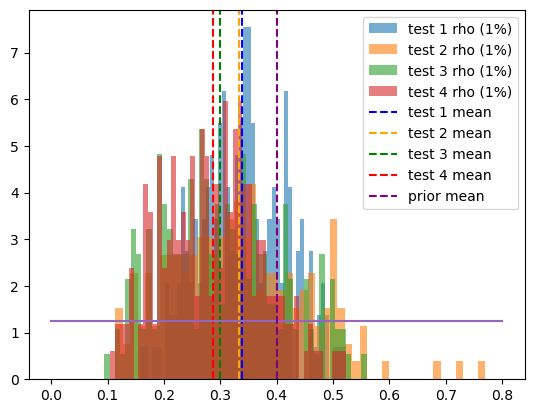

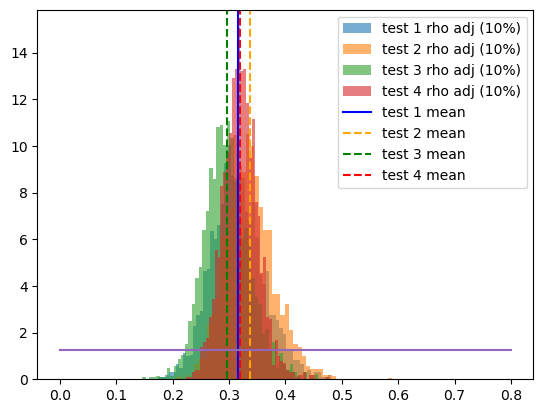

In [82]:
# rho: 1%
plt.figure()
plt.hist(rho_accepted, density = True, bins = 50, label = "test 1 rho (1%)", alpha = 0.6) 
plt.hist(rho_accepted3, density = True, bins = 50, label = "test 2 rho (1%)", alpha = 0.6) 
plt.hist(rho_accepted5, density = True, bins = 50, label = "test 3 rho (1%)", alpha = 0.6) 
plt.hist(rho_accepted7, density = True, bins = 50, label = "test 4 rho (1%)", alpha = 0.6) 
plt.axvline(x = np.mean(rho_accepted),  linestyle = '--', label = 'test 1 mean', color = 'blue')
plt.axvline(x = np.mean(rho_accepted3),  linestyle = '--', label = 'test 2 mean', color = 'orange')
plt.axvline(x = np.mean(rho_accepted5),  linestyle = '--', label = 'test 3 mean', color = 'green')
plt.axvline(x = np.mean(rho_accepted7),  linestyle = '--', label = 'test 4 mean', color = 'red')
x_axis_rho = np.linspace(0, 0.8, 100)
y_axis_rho = np.ones(100) * (1/0.8)
plt.plot(x_axis_rho, y_axis_rho)
plt.axvline(x = 0.8/2,  linestyle = '--', label = 'prior mean', color = 'purple')
plt.legend()

# rho: 10% adj
plt.figure()
plt.hist(rho_accepted2_adj, density = True, bins = 50, label = "test 1 rho adj (10%)", alpha = 0.6) 
plt.hist(rho_accepted4_adj, density = True, bins = 50, label = "test 2 rho adj (10%)", alpha = 0.6) 
plt.hist(rho_accepted6_adj, density = True, bins = 50, label = "test 3 rho adj (10%)", alpha = 0.6) 
plt.hist(rho_accepted8_adj, density = True, bins = 50, label = "test 4 rho adj (10%)", alpha = 0.6) 
plt.axvline(x = np.mean(rho_accepted2_adj),   label = 'test 1 mean', color = 'blue')
plt.axvline(x = np.mean(rho_accepted4_adj),  linestyle = '--', label = 'test 2 mean', color = 'orange')
plt.axvline(x = np.mean(rho_accepted6_adj),  linestyle = '--', label = 'test 3 mean', color = 'green')
plt.axvline(x = np.mean(rho_accepted8_adj),  linestyle = '--', label = 'test 4 mean', color = 'red')
x_axis_rho = np.linspace(0, 0.8, 100)
y_axis_rho = np.ones(100) * (1/0.8)
plt.plot(x_axis_rho, y_axis_rho)
plt.legend()
